In [309]:
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
import matplotlib.pyplot as plt
import yfinance as yf

class TradingEnv(gym.Env):
    metadata = {'render_modes': ['human']}
    
    def __init__(self, df, fee_percent=0.002, max_allocation_percent=0.20, window_size=10):
        super(TradingEnv, self).__init__()
        self.df = df.copy()
        self.fee_percent = fee_percent 
        self.max_allocation_percent = max_allocation_percent
        
        self.window_size = window_size 
        
        self.df['return'] = self.df['close'].pct_change()
        self.df['sma_10_ratio'] = (self.df['close'] / self.df['close'].rolling(window=10).mean()) - 1
        self.df['sma_30_ratio'] = (self.df['close'] / self.df['close'].rolling(window=30).mean()) - 1
        
        # RSI
        delta = self.df['close'].diff()
        up = delta.clip(lower=0)
        down = -1 * delta.clip(upper=0)
        ema_up = up.ewm(com=13, adjust=False).mean()
        ema_down = down.ewm(com=13, adjust=False).mean()
        rs = ema_up / (ema_down + 1e-8)
        self.df['rsi'] = (100 - (100 / (1 + rs))) / 100.0 
        
        # MACD
        ema_12 = self.df['close'].ewm(span=12, adjust=False).mean()
        ema_26 = self.df['close'].ewm(span=26, adjust=False).mean()
        macd = ema_12 - ema_26
        signal = macd.ewm(span=9, adjust=False).mean()
        self.df['macd_hist'] = (macd - signal) / self.df['close'] 
        
        # Bollinger Bands
        sma_20 = self.df['close'].rolling(window=20).mean()
        std_20 = self.df['close'].rolling(window=20).std()
        bb_upper = sma_20 + (2 * std_20)
        bb_lower = sma_20 - (2 * std_20)
        self.df['bb_pos'] = (self.df['close'] - bb_lower) / (bb_upper - bb_lower + 1e-8)
        
        # ATR
        high_low = self.df['high'] - self.df['low']
        high_close = np.abs(self.df['high'] - self.df['close'].shift())
        low_close = np.abs(self.df['low'] - self.df['close'].shift())
        tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        self.df['atr'] = tr.rolling(window=14).mean() / self.df['close']

        self.df = self.df.bfill().fillna(0)
        
        # rolling z score normalization
        feature_cols = ['return', 'sma_10_ratio', 'sma_30_ratio', 'rsi', 'macd_hist', 'bb_pos', 'atr', 'volume']
        for col in feature_cols:
            rolling_mean = self.df[col].rolling(window=100, min_periods=1).mean()
            rolling_std = self.df[col].rolling(window=100, min_periods=1).std()
            self.df[col] = (self.df[col] - rolling_mean) / (rolling_std + 1e-8)
            
        self.df = self.df.bfill().fillna(0)
            
        self.features = self.df[feature_cols].values
        self.close_prices = self.df['close'].values
        self.open_prices = self.df['open'].values 
        
        self.max_steps = len(self.df) - 2
        
        self.action_space = spaces.Discrete(5)
        
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.window_size * 9,), dtype=np.float32)
        
        self.initial_balance = 10000.0
        self.reset()
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.balance = self.initial_balance
        self.shares_held = 0.0
        self.current_step = 0
        self.net_worth = self.initial_balance
        self.logical_position = 0 
        self.market_history = [] 
        return self._next_observation(), {}
    
    def _next_observation(self):
        end_idx = self.current_step + 1
        start_idx = max(0, end_idx - self.window_size)
        
        window_feats = self.features[start_idx:end_idx]
        
        if len(window_feats) < self.window_size:
            pad_len = self.window_size - len(window_feats)
            padding = np.repeat(window_feats[0:1], pad_len, axis=0)
            window_feats = np.vstack([padding, window_feats])
            
        positions = np.full((self.window_size, 1), float(self.logical_position), dtype=np.float32)
        obs = np.hstack([window_feats, positions]).flatten()
        return obs.astype(np.float32) 

    def step(self, action):
        execution_price = self.open_prices[self.current_step + 1]
        
        if action == 2:  # EXIT
            if self.logical_position == 1:
                self.balance += self.shares_held * execution_price * (1 - self.fee_percent)
                self.shares_held = 0.0
                self.logical_position = 0
            elif self.logical_position == -1:
                cost = self.shares_held * execution_price * (1 + self.fee_percent)
                self.balance -= cost
                self.shares_held = 0.0
                self.logical_position = 0
                
        elif action == 0:  # ENTER_LONG
            if self.logical_position == -1:
                cost = self.shares_held * execution_price * (1 + self.fee_percent)
                self.balance -= cost
                self.shares_held = 0.0
                self.logical_position = 0
                
            if self.logical_position == 0:
                capital_to_deploy = self.balance * self.max_allocation_percent
                shares_bought = capital_to_deploy / (execution_price * (1 + self.fee_percent))
                if shares_bought > 0:
                    self.balance -= shares_bought * execution_price * (1 + self.fee_percent)
                    self.shares_held = shares_bought
                    self.logical_position = 1

        elif action == 1:  # ENTER_SHORT
            if self.logical_position == 1:
                self.balance += self.shares_held * execution_price * (1 - self.fee_percent)
                self.shares_held = 0.0
                self.logical_position = 0
                
            if self.logical_position == 0:
                capital_to_deploy = self.balance * self.max_allocation_percent
                shares_shorted = capital_to_deploy / execution_price
                if shares_shorted > 0:
                    revenue = shares_shorted * execution_price * (1 - self.fee_percent)
                    self.balance += revenue 
                    self.shares_held = shares_shorted
                    self.logical_position = -1

        elif action == 4:  # REDUCE
            if self.shares_held > 0:
                reduce_amount = self.shares_held / 2.0
                if self.logical_position == 1:
                    self.balance += reduce_amount * execution_price * (1 - self.fee_percent)
                    self.shares_held -= reduce_amount
                elif self.logical_position == -1:
                    cost = reduce_amount * execution_price * (1 + self.fee_percent)
                    self.balance -= cost
                    self.shares_held -= reduce_amount
                if self.shares_held <= 1e-6:
                    self.shares_held = 0.0
                    self.logical_position = 0
            
        self.current_step += 1
        
        # PnL
        mark_price = self.close_prices[self.current_step]
        
        if self.logical_position == 1:
            new_net_worth = self.balance + (self.shares_held * mark_price)
        elif self.logical_position == -1:
            new_net_worth = self.balance - (self.shares_held * mark_price)
        else:
            new_net_worth = self.balance
            
        bot_return = (new_net_worth - self.net_worth) / (self.net_worth + 1e-8)
        
        prev_close = self.close_prices[self.current_step - 1]
        market_return = (mark_price - prev_close) / (prev_close + 1e-8)
        self.market_history.append(market_return)
        
        recent_market_returns = self.market_history[-30:]
        market_volatility = np.std(recent_market_returns) if len(recent_market_returns) > 5 else 1e-4
        market_volatility = max(market_volatility, 1e-6) 
        
        reward = (bot_return / market_volatility) * 0.1 
        
        # deployment tax (cost of capital) vs free cash
        if self.logical_position != 0:
            reward -= 0.001 
             
        self.net_worth = new_net_worth
        terminated = bool(self.current_step >= self.max_steps)
        
        return self._next_observation(), float(reward), terminated, False, {}

    def render(self, mode='human'):
        print(f'step: {self.current_step}, position: {self.logical_position}, net worth: {self.net_worth:.2f}')

In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

train_tickers = ["AAPL", "TSLA", "MSFT", "BA", "INTC"]

def make_env(ticker):
    def _init():
        df = yf.download(ticker, start="2016-01-01", end="2022-01-01", progress=False)
        if isinstance(df.columns, pd.MultiIndex): # type: ignore
            df.columns = df.columns.droplevel(1) # type: ignore
        df.columns = [str(col).lower() for col in df.columns] # type: ignore
        df = df.dropna() # type: ignore
        return TradingEnv(df, fee_percent=0.002) 
    return _init

envs = [make_env(ticker) for ticker in train_tickers]
vec_env = DummyVecEnv(envs) # type: ignore

check_env(vec_env.envs[0]) 

model = PPO("MlpPolicy", vec_env, verbose=1, ent_coef=0.01)

train_ticker = ", ".join(train_tickers)

model.learn(total_timesteps=500000)

model.save("ppo_trading_agent_multi_new")

Fetching training data for ['AAPL', 'TSLA', 'MSFT', 'BA', 'INTC']...
Using cpu device
------------------------------
| time/              |       |
|    fps             | 17415 |
|    iterations      | 1     |
|    time_elapsed    | 0     |
|    total_timesteps | 10240 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 6359        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 20480       |
| train/                  |             |
|    approx_kl            | 0.009444043 |
|    clip_fraction        | 0.0785      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.93       |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00452     |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0115     |
|    value_loss          

[*********************100%***********************]  1 of 1 completed

test dataset META: 753 rows

Initial balance: $10,000.00
Final balance: $10,652.55
Total PnL: $652.55 (6.53%)
Buy and Hold returns: 72.89%


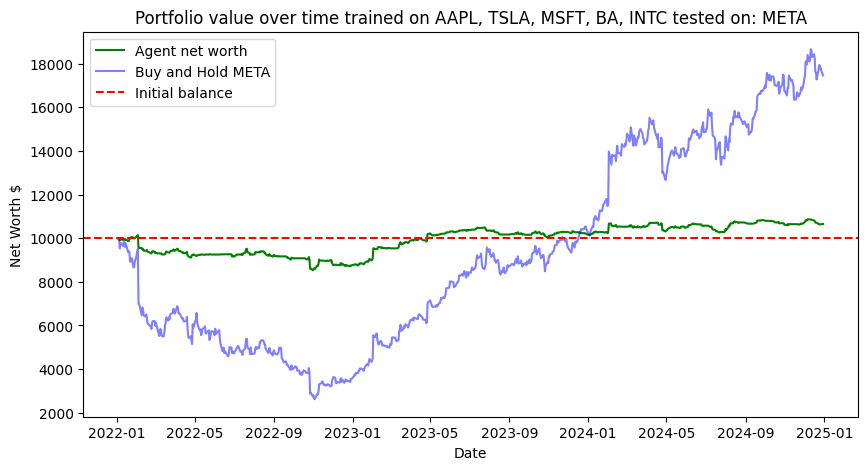

In [329]:
test_ticker = "META"
test_df = yf.download(test_ticker, start="2022-01-01", end="2025-01-01")

if test_df is None or test_df.empty:
    raise ValueError(f"no data returned for '{test_ticker}'")

if isinstance(test_df.columns, pd.MultiIndex):
    test_df.columns = test_df.columns.droplevel(1)
test_df.columns = [str(col).lower() for col in test_df.columns]
test_df = test_df.dropna()

print(f"test dataset {test_ticker}: {len(test_df)} rows")

test_env = TradingEnv(test_df, fee_percent=0.002)

obs, info = test_env.reset()
done = False

net_worths = [test_env.initial_balance]
actions_taken = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    actions_taken.append(action)
    obs, reward, terminated, truncated, info = test_env.step(action)
    
    net_worths.append(test_env.net_worth)
    done = terminated or truncated

initial = test_env.initial_balance
final = net_worths[-1]
profit = final - initial

print(f"\nInitial balance: ${initial:,.2f}")
print(f"Final balance: ${final:,.2f}")
print(f"Total PnL: ${profit:,.2f} ({(profit/initial)*100:.2f}%)")

# Buy and Hold
initial_price = float(test_env.open_prices[1])
test_max_steps = len(test_env.close_prices) - 1
final_price = float(test_env.close_prices[test_max_steps])
buy_and_hold_shares = initial / initial_price
buy_and_hold_final = buy_and_hold_shares * final_price
buy_and_hold_return = ((buy_and_hold_final - initial) / initial) * 100
print(f"Buy and Hold returns: {buy_and_hold_return:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(test_df.index[:len(net_worths)], net_worths, label='Agent net worth', color='green')

buy_hold_values = (test_df['close'][:len(net_worths)] / test_df['open'].iloc[1]) * initial
plt.plot(test_df.index[:len(net_worths)], buy_hold_values, label=f'Buy and Hold {test_ticker}', color='blue', alpha=0.5)

plt.title(f"Portfolio value over time trained on {train_ticker} tested on: {test_ticker}")
plt.xlabel("Date")
plt.ylabel("Net Worth $")
plt.axhline(initial, color='red', linestyle='--', label='Initial balance')
plt.legend()
plt.show()

In [330]:
unique_actions, counts = np.unique(actions_taken, return_counts=True)
action_names = ["ENTER_LONG", "ENTER_SHORT", "EXIT", "HOLD", "REDUCE"]

for action, count in zip(unique_actions, counts):
    if isinstance(action, np.ndarray):
        action = action.item()
    print(f"{action_names[action]}: {count} times")

ENTER_LONG: 313 times
ENTER_SHORT: 91 times
EXIT: 104 times
HOLD: 169 times
REDUCE: 74 times
